# 06 Analysis Patterns: Anomalies, Trends, and Composites
**Tutorial:** Building Geospatial Data Cubes for Earth Data Science  
**Focus:** Pine Ridge (Oglala Lakota Nation)
**Prerequisites:** Notebooks 00–05  

## What This Notebook Covers
You now know how to build a data cube, add multiple variables, slice
across time, and work with spatial data. This notebook teaches the
analytical patterns that turn raw cube data into environmental insights:

1. **Anomalies**: how far is this year from the long-term average?
2. **Trends**: is the land getting greener or less green over time?
3. **Composites**: what does a typical drought year look like vs. a wet year?
4. **Correlations**: which climate variables best explain NDVI variation?
5. **Percentile ranks**: how does this year compare to the historical record?

These are the patterns used by environmental scientists everywhere
the same techniques that appear in peer-reviewed papers, agency reports,
and Tribal land management assessments.

## A Note on Interpretation
Statistical patterns in satellite data are a starting point, not an answer.
A downward NDVI trend might mean drought, overgrazing, fire, invasive species,
or a shift in land management. Distinguishing between those causes requires
ground-level knowledge, which is why Tribal-led land observation programs
matter alongside satellite monitoring.

In [1]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
import datetime

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy import stats

from src.cube_utils import (
    fetch_ndvi_timeseries,
    fetch_gridmet_point,
    timeseries_to_dataarray,
    compute_growing_season_mean,
    compute_anomaly,
    CACHE_DIR,
)

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

PINE_RIDGE_LAT =  43.35
PINE_RIDGE_LON = -102.09
GROWING_MONTHS = [5, 6, 7, 8, 9]
START_YEAR     = 2000
END_YEAR       = 2023

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

print("Setup complete.")

Setup complete.


In [2]:
# Load multi-variable cube from notebook 04 
cube_path = CACHE_DIR/"pine_ridge_multi_variable_cube.nc"

if cube_path.exists():
    cube = xr.open_dataset(cube_path)
    print(f"Cube loaded: {list(cube.data_vars)}")
else:
    print("Multi-variable cube not found, rebuilding from cache...")
    ndvi_df  = fetch_ndvi_timeseries(
        PINE_RIDGE_LAT, PINE_RIDGE_LON, START_YEAR, END_YEAR, "pine_ridge"
    )
    tmax_df  = fetch_gridmet_point(
        PINE_RIDGE_LAT, PINE_RIDGE_LON, "tmmx", START_YEAR, END_YEAR, "pine_ridge"
    )
    tmax_df["tmmx"] = (tmax_df["tmmx"] - 273.15) * 9/5 + 32
    precip_df = fetch_gridmet_point(
        PINE_RIDGE_LAT, PINE_RIDGE_LON, "pr", START_YEAR, END_YEAR, "pine_ridge"
    )
    ndvi_da   = timeseries_to_dataarray(ndvi_df, name="ndvi").resample(time="MS").mean()
    tmax_da   = timeseries_to_dataarray(tmax_df, date_col="date", value_col="tmmx",
                                        name="tmax_f").resample(time="MS").mean()
    precip_da = timeseries_to_dataarray(precip_df, date_col="date", value_col="pr",
                                        name="precip_mm").resample(time="MS").sum()
    t0 = max(pd.Timestamp(ndvi_da.time.values[0]),
             pd.Timestamp(tmax_da.time.values[0]),
             pd.Timestamp(precip_da.time.values[0]))
    t1 = min(pd.Timestamp(ndvi_da.time.values[-1]),
             pd.Timestamp(tmax_da.time.values[-1]),
             pd.Timestamp(precip_da.time.values[-1]))
    cube = xr.Dataset({
        "ndvi":      ndvi_da.sel(time=slice(t0, t1)),
        "tmax_f":    tmax_da.sel(time=slice(t0, t1)),
        "precip_mm": precip_da.sel(time=slice(t0, t1)),
    })

ndvi   = cube["ndvi"]
tmax   = cube["tmax_f"]
precip = cube["precip_mm"]

# Annual growing season means
gs_mask       = cube.time.dt.month.isin(GROWING_MONTHS)
ndvi_annual   = compute_growing_season_mean(ndvi, GROWING_MONTHS)
tmax_annual   = compute_growing_season_mean(tmax, GROWING_MONTHS)
precip_annual = cube["precip_mm"].sel(time=gs_mask).groupby("time.year").sum()

years = ndvi_annual.year.values.astype(int)
print(f"Analysis period: {years[0]}–{years[-1]}  ({len(years)} years)")

Cube loaded: ['ndvi', 'tmax_f', 'precip_mm']
Analysis period: 2000–2023  (24 years)


---
## Pattern 1: Anomalies

An anomaly is the departure of a value from the long-term average.
It answers: *"Was this year unusual, and by how much?"*

Anomalies are more informative than raw values when comparing across
variables with different units. You can put NDVI anomaly and
precipitation anomaly on the same scale.

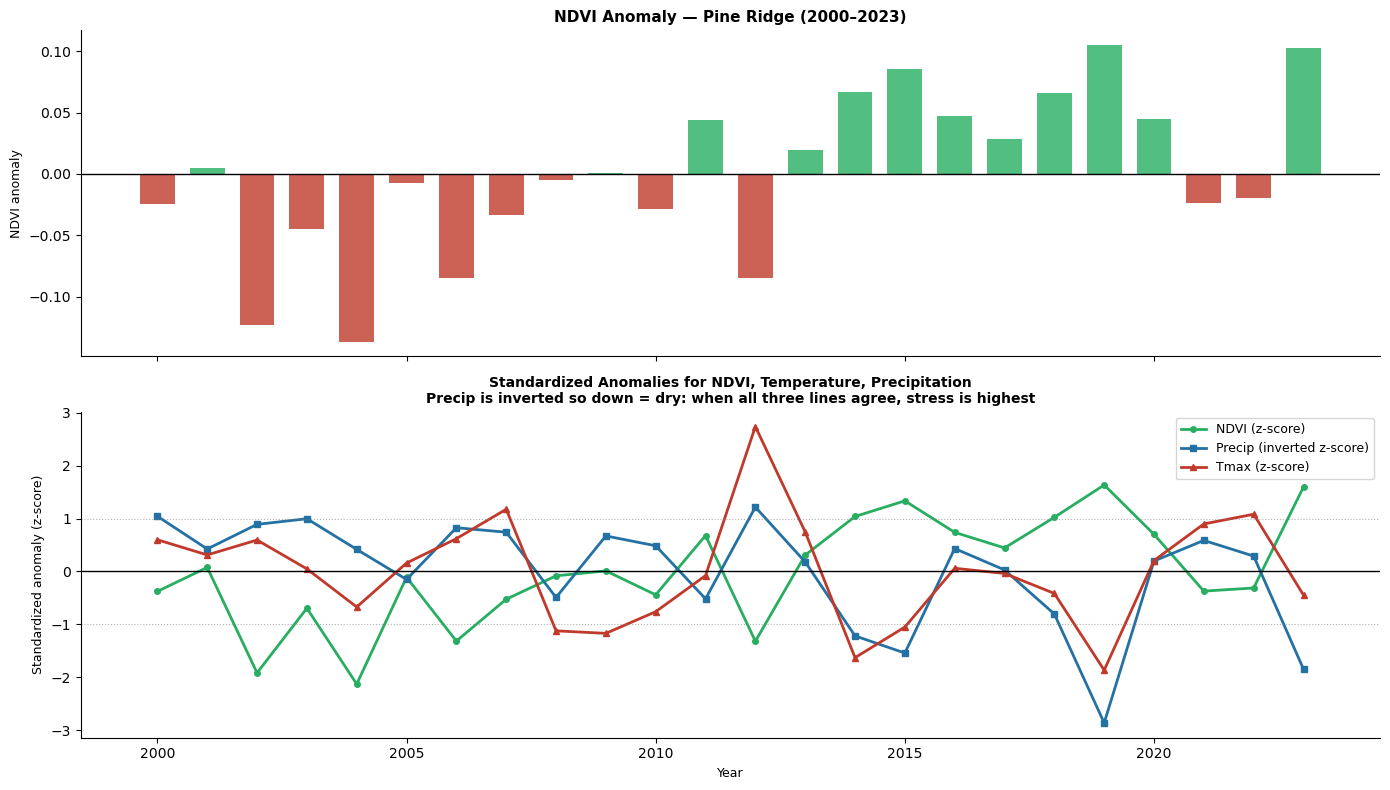

Top 5 highest compound stress years:
 year  ndvi_z  tmax_z  precip_z  compound_z
 2012   -1.32    2.74     -1.22        5.28
 2002   -1.92    0.59     -0.89        3.40
 2006   -1.32    0.62     -0.83        2.77
 2007   -0.52    1.18     -0.74        2.44
 2000   -0.38    0.60     -1.04        2.02


In [3]:
# Compute anomalies for all three variables
ndvi_anom   = compute_anomaly(ndvi_annual)
tmax_anom   = compute_anomaly(tmax_annual)
precip_anom = compute_anomaly(precip_annual)

# Standardized anomaly (z-score): anomaly divided by standard deviation
# This puts all variables on the same scale so you can compare them directly
ndvi_z   = ndvi_anom   / float(ndvi_annual.std())
tmax_z   = tmax_anom   / float(tmax_annual.std())
precip_z = precip_anom / float(precip_annual.std())

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Raw anomalies
ax = axes[0]
ax.bar(years, ndvi_anom.values, color=[
    "#C0392B" if v < 0 else "#27AE60" for v in ndvi_anom.values
], alpha=0.8, width=0.7, label="NDVI anomaly")
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("NDVI anomaly", fontsize=9)
ax.set_title("NDVI Anomaly — Pine Ridge (2000–2023)", fontsize=11, fontweight="bold")
despine(ax)

# Standardized anomalies with all three variables on same axis
ax = axes[1]
ax.plot(years, ndvi_z.values,   color="#27AE60", linewidth=2,
        marker="o", markersize=4, label="NDVI (z-score)")
ax.plot(years, -precip_z.values, color="#2471A3", linewidth=2,
        marker="s", markersize=4, label="Precip (inverted z-score)")
ax.plot(years, tmax_z.values,   color="#C0392B", linewidth=2,
        marker="^", markersize=4, label="Tmax (z-score)")
ax.axhline(0,   color="black", linewidth=1)
ax.axhline(-1,  color="gray",  linewidth=0.8, linestyle=":", alpha=0.6)
ax.axhline( 1,  color="gray",  linewidth=0.8, linestyle=":", alpha=0.6)
ax.set_ylabel("Standardized anomaly (z-score)", fontsize=9)
ax.set_xlabel("Year", fontsize=9)
ax.set_title(
    "Standardized Anomalies for NDVI, Temperature, Precipitation\n"
    "Precip is inverted so down = dry: when all three lines agree, stress is highest",
    fontsize=10, fontweight="bold",
)
ax.legend(fontsize=9)
despine(ax)

plt.tight_layout()
plt.show()

# Most anomalous years
anom_df = pd.DataFrame({
    "year":       years,
    "ndvi_z":     ndvi_z.values.round(2),
    "tmax_z":     tmax_z.values.round(2),
    "precip_z":   precip_z.values.round(2),
})
anom_df["compound_z"] = (
    -anom_df["ndvi_z"] + anom_df["tmax_z"] - anom_df["precip_z"]
).round(2)

print("Top 5 highest compound stress years:")
print(anom_df.nlargest(5, "compound_z")[["year","ndvi_z","tmax_z","precip_z","compound_z"]].to_string(index=False))

## Pattern 2: Trends
A trend answers: *"Is the land changing over time, and how fast?"*

We use the Theil-Sen slope here, which is a robust trend estimator that isn't
pulled by extreme outlier years the way ordinary linear regression is.
This is the standard method for trend detection in environmental time series.

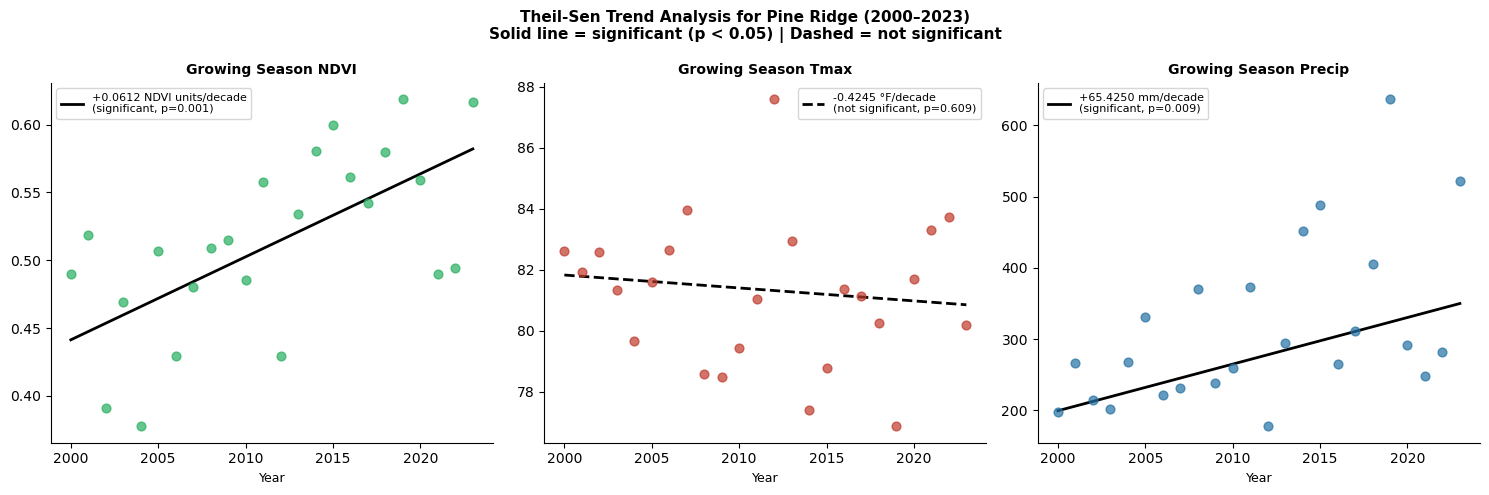

TREND SUMMARY
  NDVI    : +0.0612 NDVI units/decade  significant (p=0.001)
  Tmax    : -0.4245 °F/decade    not significant (p=0.609)
  Precip  : +65.4250 mm/decade  significant (p=0.009)


In [11]:
# Theil-Sen slope for NDVI, temperature, and precipitation
def theilsen_trend(years, values):
    """Returns slope, intercept, p-value, and trend line values."""
    mask  = ~np.isnan(values)
    yrs   = years[mask].astype(float)
    vals  = values[mask]
    slope, intercept, _, _ = stats.theilslopes(vals, yrs)
    _, _, _, p, _          = stats.linregress(yrs, vals)
    trend_line             = slope * years.astype(float) + intercept
    return slope, intercept, p, trend_line

ndvi_slope,   _, ndvi_p,   ndvi_trend   = theilsen_trend(years, ndvi_annual.values)
tmax_slope,   _, tmax_p,   tmax_trend   = theilsen_trend(years, tmax_annual.values)
precip_slope, _, precip_p, precip_trend = theilsen_trend(years, precip_annual.values)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, annual, trend, slope, p, label, color, unit in [
    (axes[0], ndvi_annual,   ndvi_trend,   ndvi_slope,   ndvi_p,
     "NDVI",  "#27AE60", "NDVI units"),
    (axes[1], tmax_annual,   tmax_trend,   tmax_slope,   tmax_p,
     "Tmax",  "#C0392B", "°F"),
    (axes[2], precip_annual, precip_trend, precip_slope, precip_p,
     "Precip","#2471A3", "mm"),
]:
    ax.scatter(years, annual.values, color=color, s=40, alpha=0.7, zorder=3)
    sig = p < 0.05
    ax.plot(
        years, trend,
        color="black", linewidth=2,
        linestyle="-" if sig else "--",
        label=f"{slope*10:+.4f} {unit}/decade\n"
              f"({'significant' if sig else 'not significant'}, p={p:.3f})",
    )
    ax.set_title(f"Growing Season {label}", fontweight="bold", fontsize=10)
    ax.set_xlabel("Year", fontsize=9)
    ax.legend(fontsize=8)
    despine(ax)

plt.suptitle(
    "Theil-Sen Trend Analysis for Pine Ridge (2000–2023)\n"
    "Solid line = significant (p < 0.05) | Dashed = not significant",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

print("TREND SUMMARY")
for label, slope, p, unit in [
    ("NDVI",   ndvi_slope,   ndvi_p,   "NDVI units"),
    ("Tmax",   tmax_slope,   tmax_p,   "°F"),
    ("Precip", precip_slope, precip_p, "mm"),
]:
    sig = "significant" if p < 0.05 else "  not significant"
    print(f"  {label:<8}: {slope*10:+.4f} {unit}/decade  {sig} (p={p:.3f})")

## Pattern 3: Composites
A composite is the average of multiple years that share a common condition,
for example, the average of all drought years, or the average of all wet years.
Composites reveal the "typical" pattern associated with a condition.

In [5]:
# Classify years as drought, near-normal, or wet
# based on growing season precipitation anomaly

precip_std = float(precip_annual.std())
precip_mean = float(precip_annual.mean())

year_classes = {}
for yr, val in zip(years, precip_annual.values):
    z = (val - precip_mean) / precip_std
    if z < -0.75:
        year_classes[int(yr)] = "Drought"
    elif z > 0.75:
        year_classes[int(yr)] = "Wet"
    else:
        year_classes[int(yr)] = "Near-normal"

drought_years = [yr for yr, cls in year_classes.items() if cls == "Drought"]
wet_years     = [yr for yr, cls in year_classes.items() if cls == "Wet"]
normal_years  = [yr for yr, cls in year_classes.items() if cls == "Near-normal"]

print(f"Drought years    ({len(drought_years)}): {drought_years}")
print(f"Wet years        ({len(wet_years)}):     {wet_years}")
print(f"Near-normal years ({len(normal_years)}): {normal_years}")

Drought years    (5): [2000, 2002, 2003, 2006, 2012]
Wet years        (5):     [2014, 2015, 2018, 2019, 2023]
Near-normal years (14): [2001, 2004, 2005, 2007, 2008, 2009, 2010, 2011, 2013, 2016, 2017, 2020, 2021, 2022]


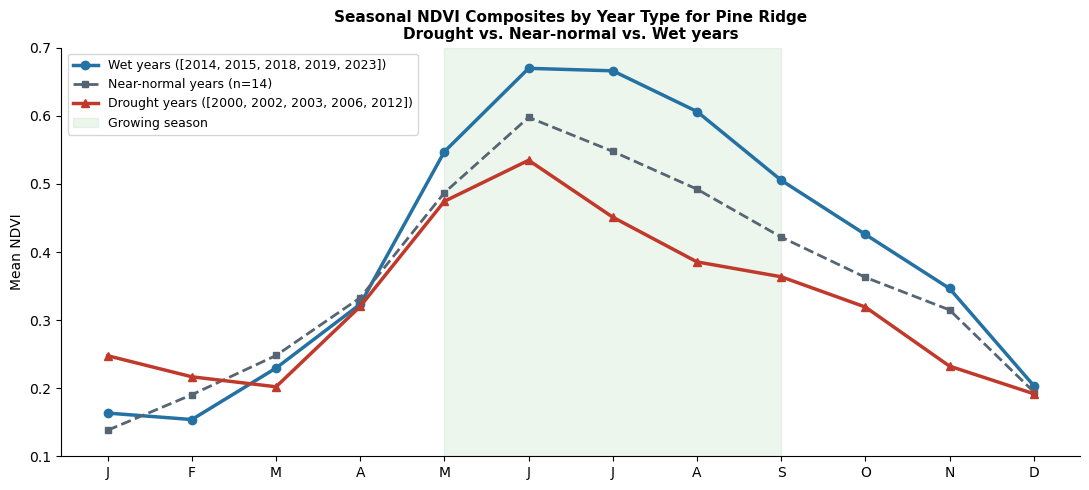

Peak growing season NDVI in wet years:    0.6697
Peak growing season NDVI in drought years: 0.5347
Drought suppresses peak NDVI by: +0.1350 (20.2%)


In [6]:
# Compute monthly NDVI composite for each class
def monthly_composite(ndvi_da, year_list):
    """Mean monthly NDVI across all years in year_list."""
    selected = ndvi_da.sel(
        time=ndvi_da.time.dt.year.isin(year_list)
    )
    return selected.groupby("time.month").mean()

drought_comp = monthly_composite(ndvi, drought_years)
wet_comp     = monthly_composite(ndvi, wet_years)
normal_comp  = monthly_composite(ndvi, normal_years)

month_labels = ["J","F","M","A","M","J","J","A","S","O","N","D"]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(range(1,13), wet_comp.values,
        color="#2471A3", linewidth=2.5, marker="o",
        markersize=6, label=f"Wet years ({wet_years})")
ax.plot(range(1,13), normal_comp.values,
        color="#566573", linewidth=2, marker="s",
        markersize=5, linestyle="--",
        label=f"Near-normal years (n={len(normal_years)})")
ax.plot(range(1,13), drought_comp.values,
        color="#C0392B", linewidth=2.5, marker="^",
        markersize=6, label=f"Drought years ({drought_years})")

# Shade growing season
ax.axvspan(5, 9, alpha=0.07, color="green", label="Growing season")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_ylabel("Mean NDVI", fontsize=10)
ax.set_title(
    "Seasonal NDVI Composites by Year Type for Pine Ridge\n"
    "Drought vs. Near-normal vs. Wet years",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9)
ax.set_ylim(0.1, 0.7)
despine(ax)
plt.tight_layout()
plt.show()

# How much does drought suppress peak NDVI?
peak_drought = float(drought_comp.max())
peak_wet     = float(wet_comp.max())
print(f"Peak growing season NDVI in wet years:    {peak_wet:.4f}")
print(f"Peak growing season NDVI in drought years: {peak_drought:.4f}")
print(f"Drought suppresses peak NDVI by: {peak_wet - peak_drought:+.4f} "
      f"({(peak_wet - peak_drought)/peak_wet*100:.1f}%)")

## Pattern 4: Correlations
Which variable, temperature or precipitation, best explains
year-to-year NDVI variation on Pine Ridge?

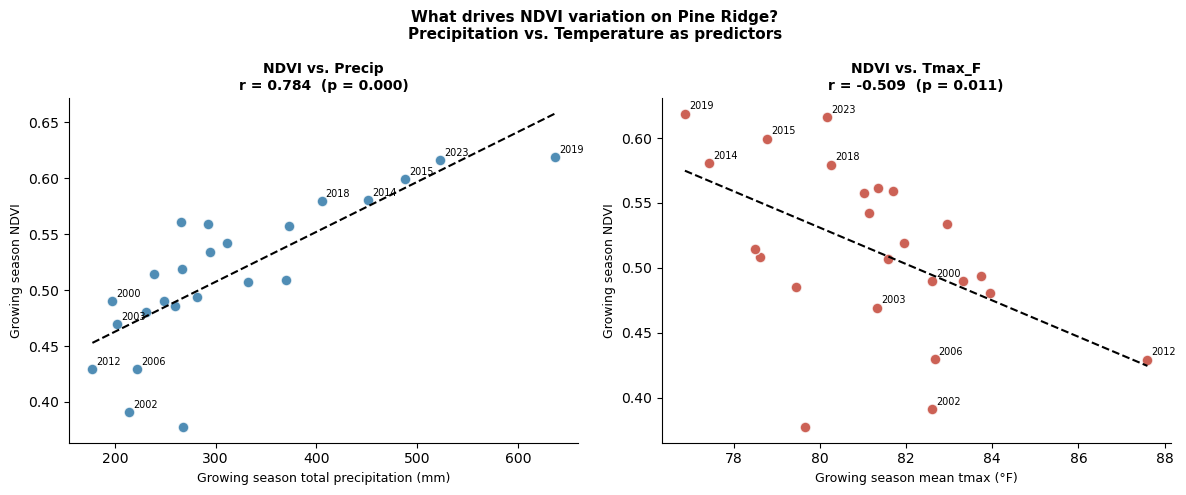

Correlation summary:
         NDVI  Tmax_F  Precip
NDVI    1.000  -0.509   0.784
Tmax_F -0.509   1.000  -0.681
Precip  0.784  -0.681   1.000

NDVI is more strongly correlated with precipitation.


In [7]:
# Correlation matrix between annual growing season variables
corr_df = pd.DataFrame({
    "NDVI":   ndvi_annual.values,
    "Tmax_F": tmax_annual.values,
    "Precip": precip_annual.values,
}, index=years)

corr_matrix = corr_df.corr()

# Pairwise scatter plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, x_col, x_label in [
    (axes[0], "Precip", "Growing season total precipitation (mm)"),
    (axes[1], "Tmax_F", "Growing season mean tmax (°F)"),
]:
    r, p = stats.pearsonr(
        corr_df[x_col].dropna(),
        corr_df.loc[corr_df[x_col].notna(), "NDVI"]
    )
    color = "#2471A3" if x_col == "Precip" else "#C0392B"

    ax.scatter(corr_df[x_col], corr_df["NDVI"],
               color=color, s=60, alpha=0.8, edgecolors="white")

    # Regression line
    x_range = np.linspace(corr_df[x_col].min(), corr_df[x_col].max(), 50)
    slope, intercept, *_ = stats.linregress(
        corr_df[x_col].dropna(),
        corr_df.loc[corr_df[x_col].notna(), "NDVI"]
    )
    ax.plot(x_range, slope * x_range + intercept,
            color="black", linewidth=1.5, linestyle="--")

    # Label notable years
    for yr in drought_years + wet_years:
        if yr in corr_df.index:
            ax.annotate(str(yr),
                        (corr_df.loc[yr, x_col], corr_df.loc[yr, "NDVI"]),
                        fontsize=7, xytext=(3, 3),
                        textcoords="offset points")

    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel("Growing season NDVI", fontsize=9)
    ax.set_title(
        f"NDVI vs. {x_col}\nr = {r:.3f}  (p = {p:.3f})",
        fontsize=10, fontweight="bold",
    )
    despine(ax)

plt.suptitle(
    "What drives NDVI variation on Pine Ridge?\n"
    "Precipitation vs. Temperature as predictors",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

print("Correlation summary:")
print(corr_matrix.round(3).to_string())
r_precip = corr_matrix.loc["NDVI", "Precip"]
r_tmax   = corr_matrix.loc["NDVI", "Tmax_F"]
stronger = "precipitation" if abs(r_precip) > abs(r_tmax) else "temperature"
print(f"\nNDVI is more strongly correlated with {stronger}.")

---
## Pattern 5: Percentile Ranks

A percentile rank answers: *"How does this year compare to every
other year in the record?"* The 10th percentile is worse than 90% of
years. The 90th percentile is better than 90% of years.

Percentile ranks are more intuitive for non-technical audiences
than z-scores or raw NDVI values.

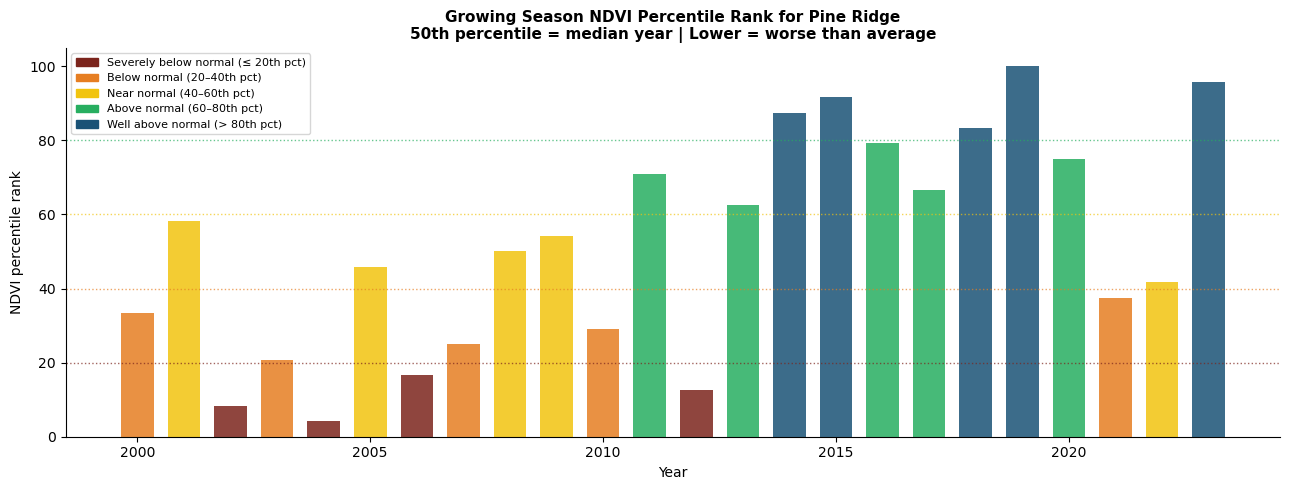

Worst 5 years (lowest NDVI percentile):
 year  ndvi_mean  pct_rank
 2004     0.3775       4.2
 2002     0.3911       8.3
 2012     0.4294      12.5
 2006     0.4296      16.7
 2003     0.4695      20.8

Best 5 years (highest NDVI percentile):
 year  ndvi_mean  pct_rank
 2018     0.5796      83.3
 2014     0.5806      87.5
 2015     0.5996      91.7
 2023     0.6164      95.8
 2019     0.6188     100.0


In [9]:
# Compute percentile rank for each year's growing season NDVI
from scipy.stats import percentileofscore

all_vals = ndvi_annual.values
pct_ranks = np.array([
    percentileofscore(all_vals, v, kind="rank")
    for v in all_vals
])

pct_df = pd.DataFrame({
    "year":       years,
    "ndvi_mean":  all_vals.round(4),
    "pct_rank":   pct_ranks.round(1),
}).sort_values("pct_rank")

fig, ax = plt.subplots(figsize=(13, 5))

def pct_color(p):
    if p <= 20:  return "#7B241C"
    if p <= 40:  return "#E67E22"
    if p <= 60:  return "#F1C40F"
    if p <= 80:  return "#27AE60"
    return               "#1A5276"

bar_colors = [pct_color(p) for p in pct_ranks]
ax.bar(years, pct_ranks, color=bar_colors, alpha=0.85, width=0.7)

for threshold, label, color in [
    (20, "Severely below normal", "#7B241C"),
    (40, "Below normal",          "#E67E22"),
    (60, "Near normal",           "#F1C40F"),
    (80, "Above normal",          "#27AE60"),
]:
    ax.axhline(threshold, color=color, linewidth=1,
               linestyle=":", alpha=0.7)

ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("NDVI percentile rank", fontsize=10)
ax.set_title(
    "Growing Season NDVI Percentile Rank for Pine Ridge\n"
    "50th percentile = median year | Lower = worse than average",
    fontsize=11, fontweight="bold",
)
ax.set_ylim(0, 105)
ax.legend(
    handles=[
        mpatches.Patch(color="#7B241C", label="Severely below normal (≤ 20th pct)"),
        mpatches.Patch(color="#E67E22", label="Below normal (20–40th pct)"),
        mpatches.Patch(color="#F1C40F", label="Near normal (40–60th pct)"),
        mpatches.Patch(color="#27AE60", label="Above normal (60–80th pct)"),
        mpatches.Patch(color="#1A5276", label="Well above normal (> 80th pct)"),
    ],
    fontsize=8, loc="upper left",
)
despine(ax)
plt.tight_layout()
plt.show()

print("Worst 5 years (lowest NDVI percentile):")
print(pct_df.head(5).to_string(index=False))
print("\nBest 5 years (highest NDVI percentile):")
print(pct_df.tail(5).to_string(index=False))

## Summary: Analysis Patterns
| Pattern | What it answers | Key function |
|---|---|---|
| Anomaly | How far from the average? | `da - da.mean()` |
| Z-score | How many standard deviations? | `anomaly / da.std()` |
| Trend | Is it changing over time? | `scipy.stats.theilslopes()` |
| Composite | What does a typical drought year look like? | `.sel(time=...).groupby("time.month").mean()` |
| Correlation | Which variable drives NDVI? | `scipy.stats.pearsonr()` |
| Percentile | How does this year rank? | `scipy.stats.percentileofscore()` |

## Discussion Questions
1. Look at the trend results. Is the NDVI trend statistically significant?
   What would it mean for Pine Ridge land management if the trend is
   genuinely declining, and what alternative explanations should you
   consider before drawing that conclusion?

2. The composite analysis groups years as drought, near-normal, and wet
   based on precipitation. What other criteria could you use to classify
   years, for example, using NDVI itself, or temperature, or a
   combination? How would different classification criteria change
   the composites?

3. The percentile rank chart is designed to be understandable to a
   non-technical audience. What would you add or change to make it
   useful for a presentation to Tribal land managers or a Tribal council?

## Next Notebook
**07 Open Data Cube Intro:** We step up to ODC the production-scale
platform that adds indexing, cataloging, and cloud-scale access on top
of the xarray foundations you have built here.